In [1]:
import pandas as pd
import numpy as np

athletes = pd.read_csv("athlete_events.csv")
regions = pd.read_csv("noc_regions.csv")

In [2]:
df = athletes.merge(regions, on="NOC", how="left")

In [3]:
df.shape

(271116, 17)

In [4]:
df.dtypes

ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
region     object
notes      object
dtype: object

# Data Cleaning

In [5]:
df['notes'].isna().mean()

0.9814138597500701

In [6]:
df.drop(columns='notes', inplace=True)

In [7]:
df['Medal'] = df['Medal'].fillna('No Medal')

df['medal_flag'] = (df['Medal'] != 'No Medal').astype(int)

In [8]:
df.describe()

,ID,Age,Height,Weight,Year,medal_flag
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480,0.146738
std,39022.286345,6.393561,10.518462,14.348020,29.877632,0.353845
min,1.000000,10.000000,127.000000,25.000000,1896.000000,0.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000,0.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000,0.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000,0.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000,1.000000


In [9]:
df.isnull().sum()

ID                0
Name              0
Sex               0
Age            9474
Height        60171
Weight        62875
Team              0
NOC               0
Games             0
Year              0
Season            0
City              0
Sport             0
Event             0
Medal             0
region          370
medal_flag        0
dtype: int64

In [10]:
df[df['region'].isnull()].Team.unique()

array(['Singapore', 'Refugee Olympic Athletes', 'June Climene', 'Unknown',
       'Tuvalu', 'Rika II', 'Singapore-2', 'Singapore-1'], dtype=object)

In [11]:
df.loc[df['Team'].str.contains('Singapore', na=False), 'region'] = 'Singapore'

In [12]:
df[df['region'].isnull()].shape

(28, 17)

In [13]:
df.loc[df['Team'] == 'Tuvalu', 'region'] = 'Tuvalu'

In [14]:
df.loc[df['Team'] == 'Refugee Olympic Athletes', 'region'] = 'Refugee Team'

In [15]:
invalid_teams = ['June Climene','Rika II','Unknown']

df = df[~df['Team'].isin(invalid_teams)]

In [16]:
df[df['region'].isnull()]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,medal_flag


In [17]:
df.isnull().sum()

ID                0
Name              0
Sex               0
Age            9471
Height        60166
Weight        62870
Team              0
NOC               0
Games             0
Year              0
Season            0
City              0
Sport             0
Event             0
Medal             0
region            0
medal_flag        0
dtype: int64

In [18]:
df['Age'] = df['Age'].fillna(
    df.groupby('Sport')['Age'].transform('median')
)

In [19]:
df['Height'] = df['Height'].fillna(
    df.groupby('Sport')['Height'].transform('median')
)

In [20]:
df['Weight'] = df['Weight'].fillna(
    df.groupby('Sport')['Weight'].transform('median')
)

In [21]:
df[['Age','Height','Weight']].isnull().sum()

Age         0
Height     99
Weight    217
dtype: int64

In [22]:
df['Height'].fillna(df['Height'].median(), inplace=True)
df['Weight'].fillna(df['Weight'].median(), inplace=True)

/tmp/ipykernel_148/3350220066.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Height'].fillna(df['Height'].median(), inplace=True)
/tmp/ipykernel_148/3350220066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [23]:
df[['Age','Height','Weight']].isnull().sum()

Age       0
Height    0
Weight    0
dtype: int64

In [24]:
df.isnull().sum()

ID            0
Name          0
Sex           0
Age           0
Height        0
Weight        0
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
region        0
medal_flag    0
dtype: int64

In [25]:
df.duplicated().sum()

1385

In [26]:
df = df.drop_duplicates()

In [27]:
df.duplicated().sum()

0

In [28]:
df.dtypes

ID              int64
Name           object
Sex            object
Age           float64
Height        float64
Weight        float64
Team           object
NOC            object
Games          object
Year            int64
Season         object
City           object
Sport          object
Event          object
Medal          object
region         object
medal_flag      int64
dtype: object

In [29]:
df['medal_flag'] = np.where(df['Medal']!='No Medal',1,0)

In [30]:
df['decade'] = (df['Year']//10)*10

In [31]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region',
       'medal_flag', 'decade'],
      dtype='object')

In [32]:
df.columns = df.columns.str.lower()

In [33]:
df.columns

Index(['id', 'name', 'sex', 'age', 'height', 'weight', 'team', 'noc', 'games',
       'year', 'season', 'city', 'sport', 'event', 'medal', 'region',
       'medal_flag', 'decade'],
      dtype='object')

In [34]:
df.describe()

,id,age,height,weight,year,medal_flag,decade
count,269722.000000,269722.000000,269722.000000,269722.00000,269722.000000,269722.000000,269722.000000
mean,68265.763019,25.478952,175.171480,70.51539,1978.624109,0.147456,1974.421182
std,39026.580734,6.132447,9.684269,13.08798,29.751806,0.354560,29.869246
min,1.000000,10.000000,127.000000,25.00000,1896.000000,0.000000,1890.000000
25%,34656.000000,22.000000,169.000000,62.00000,1960.000000,0.000000,1960.000000
50%,68235.500000,25.000000,175.000000,70.00000,1988.000000,0.000000,1980.000000
75%,102111.000000,28.000000,181.000000,77.00000,2002.000000,0.000000,2000.000000
max,135571.000000,97.000000,226.000000,214.00000,2016.000000,1.000000,2010.000000


In [35]:
df.head()

,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal,region,medal_flag,decade
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,0,1990
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,0,2010
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,71.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark,0,1920
3,4,Edgar Lindenau Aabye,M,34.0,182.0,95.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,1,1900
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal,Netherlands,0,1980


# Exploratory Data Analysis

In [36]:
df['name'].nunique()

134724

In [37]:
df['region'].nunique()

208

In [38]:
df['sport'].nunique()

66

In [39]:
df['games'].nunique()

51

In [40]:
df.head()

,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal,region,medal_flag,decade
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,0,1990
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,0,2010
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,71.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark,0,1920
3,4,Edgar Lindenau Aabye,M,34.0,182.0,95.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,1,1900
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal,Netherlands,0,1980


In [41]:
df.shape

(269722, 18)

In [43]:
df['BMI'] = df['weight'] / ((df['height']/100) ** 2)
df['BMI'] = df['BMI'].round(2)

In [45]:
df[['height','weight','BMI']].head()

,height,weight,BMI
0,180.0,80.0,24.69
1,170.0,60.0,20.76
2,175.0,71.0,23.18
3,182.0,95.0,28.68
4,185.0,82.0,23.96


In [55]:
athletes_by_decade = df.groupby('decade')['name'].count().reset_index(name = 'total_athletes')\
                       .sort_values(by = 'total_athletes', ascending =False)
athletes_by_decade

,decade,total_athletes
11,2000,49357
10,1990,36958
12,2010,35901
9,1980,35201
7,1960,29191
8,1970,22461
6,1950,15788
3,1920,15100
4,1930,9963
1,1900,8001


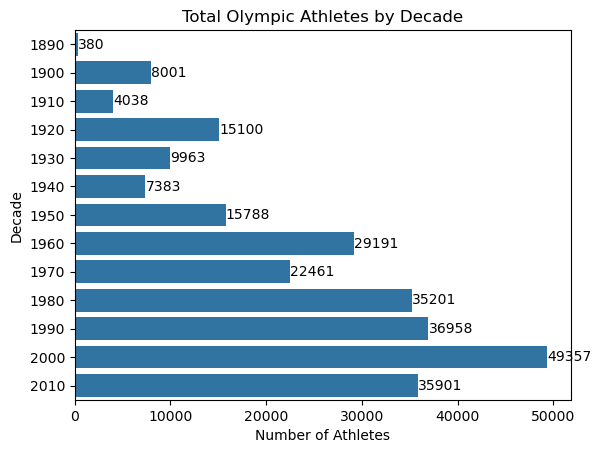

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(
    data=athletes_by_decade,
    x='total_athletes',
    y='decade',
    orient = 'h'
)

plt.title('Total Olympic Athletes by Decade')
plt.xlabel('Number of Athletes')
plt.ylabel('Decade')
for i in ax.containers:
    ax.bar_label(i)

plt.show()

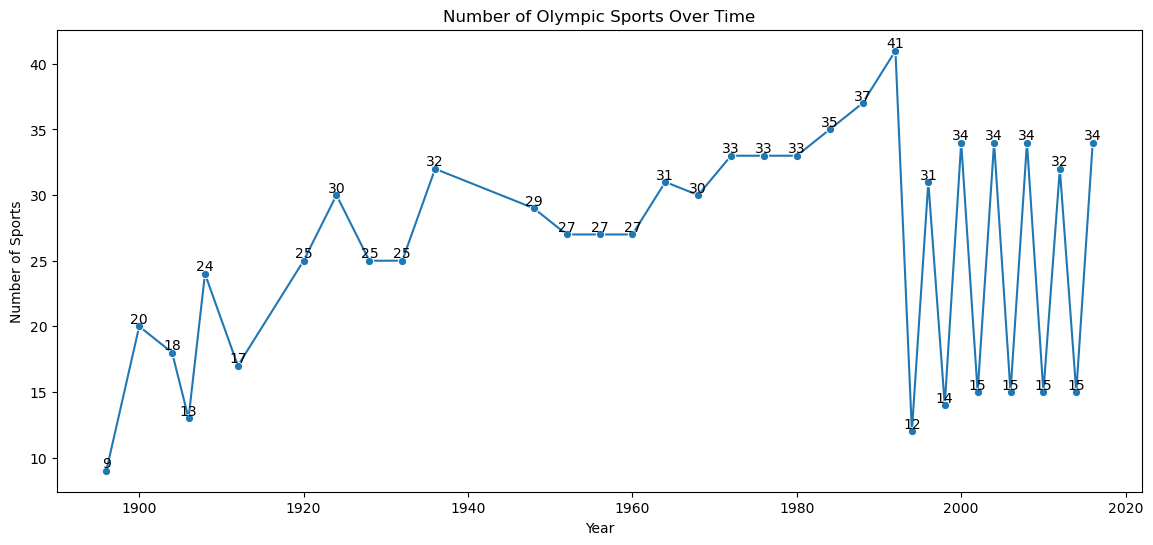

In [67]:
sports_over_time = (
    df.groupby('year')['sport']
    .nunique()
    .reset_index(name='num_sports')
)
plt.figure(figsize=(14,6))

ax = sns.lineplot(
    data=sports_over_time,
    x='year',
    y='num_sports',
    marker='o'
)

for x, y in zip(sports_over_time['year'], sports_over_time['num_sports']):
    ax.text(x, y, str(y), ha='center', va='bottom')

plt.title('Number of Olympic Sports Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Sports')

plt.show()

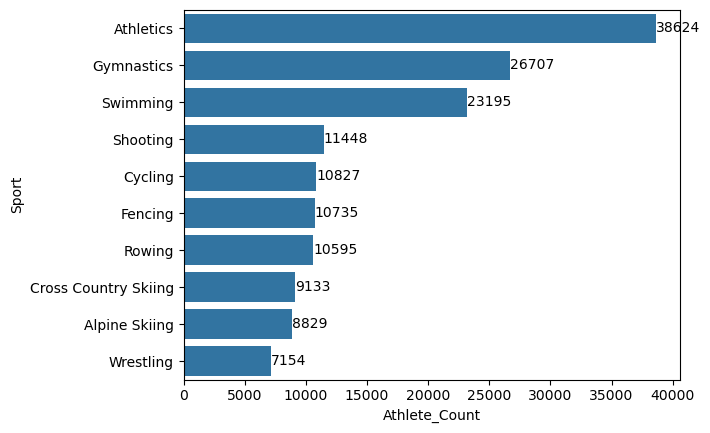

In [70]:
top_sports = (
    df['sport']
    .value_counts()
    .head(10)
    .reset_index()
)

top_sports.columns = ['Sport','Athlete_Count']

ax = sns.barplot(
    data=top_sports,
    x='Athlete_Count',
    y='Sport'
)
for i in ax.containers:
    ax.bar_label(i)

# Analysis for Hypothesis 1

In [80]:
country_medals = df.groupby(['year','region'])['medal_flag'].sum().reset_index(name = 'Country total medals')
total_medals_year = df.groupby('year')['medal_flag'].sum().reset_index(name ='Olympic total medals')
country_medals = country_medals.merge(total_medals_year, on='year')
country_medals['medal_share_pct'] = (
country_medals['Country total medals'] / country_medals['Olympic total medals'] * 100).round(2)
country_medals = country_medals.sort_values(
    ['year','medal_share_pct'],
    ascending=[True, False]
)
country_medals

,year,region,Country total medals,Olympic total medals,medal_share_pct
5,1896,Greece,48,143,33.57
4,1896,Germany,32,143,22.38
11,1896,USA,20,143,13.99
3,1896,France,11,143,7.69
10,1896,UK,9,143,6.29
...,...,...,...,...,...
3273,2016,"Virgin Islands, British",0,2023,0.00
3274,2016,"Virgin Islands, US",0,2023,0.00
3275,2016,Yemen,0,2023,0.00
3276,2016,Zambia,0,2023,0.00


In [101]:
top_countries = (
    df.groupby('region')['medal_flag']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)
top_countries[10:15]

Index(['Netherlands', 'Norway', 'China', 'Japan', 'Finland'], dtype='object', name='region')

In [102]:
dominant_df = country_medals[
    country_medals['region'].isin(top_countries[10:15])
]
dominant_df

,year,region,Country total medals,Olympic total medals,medal_share_pct
32,1900,Netherlands,27,593,4.55
34,1900,Norway,9,593,1.52
52,1904,Norway,2,486,0.41
71,1906,Norway,25,458,5.46
70,1906,Netherlands,6,458,1.31
...,...,...,...,...,...
3111,2016,China,113,2023,5.59
3161,2016,Japan,64,2023,3.16
3199,2016,Netherlands,47,2023,2.32
3205,2016,Norway,19,2023,0.94


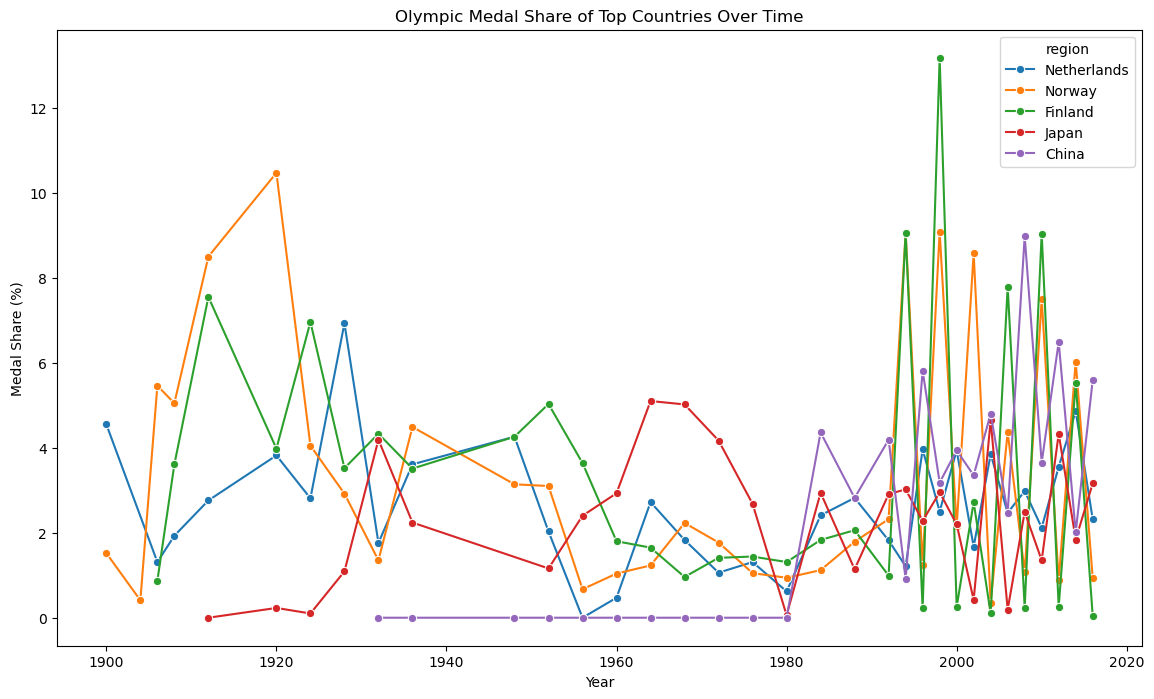

In [103]:
plt.figure(figsize=(14,8))

ax = sns.lineplot(
    data=dominant_df,
    x='year',
    y='medal_share_pct',
    hue='region',
    marker='o'
)

plt.title('Olympic Medal Share of Top Countries Over Time')
plt.ylabel('Medal Share (%)')
plt.xlabel('Year')
plt.show()

# Analysis for Hypothesis 2

In [104]:
df['sport'].unique()

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Speed Skating',
       'Cross Country Skiing', 'Athletics', 'Ice Hockey', 'Swimming',
       'Badminton', 'Sailing', 'Biathlon', 'Gymnastics',
       'Art Competitions', 'Alpine Skiing', 'Handball', 'Weightlifting',
       'Wrestling', 'Luge', 'Water Polo', 'Hockey', 'Rowing', 'Bobsleigh',
       'Fencing', 'Equestrianism', 'Shooting', 'Boxing', 'Taekwondo',
       'Cycling', 'Diving', 'Canoeing', 'Tennis', 'Modern Pentathlon',
       'Figure Skating', 'Golf', 'Softball', 'Archery', 'Volleyball',
       'Synchronized Swimming', 'Table Tennis', 'Nordic Combined',
       'Baseball', 'Rhythmic Gymnastics', 'Freestyle Skiing',
       'Rugby Sevens', 'Trampolining', 'Beach Volleyball', 'Triathlon',
       'Ski Jumping', 'Curling', 'Snowboarding', 'Rugby',
       'Short Track Speed Skating', 'Skeleton', 'Lacrosse', 'Polo',
       'Cricket', 'Racquets', 'Motorboating', 'Military Ski Patrol',
       'Croquet', 'Jeu De Paume', 'Roque', 'Al

In [111]:
height_advantage_sports = [
    'Basketball',
    'Volleyball',
    'Rowing',
    'Swimming'
]

weight_advantage_sports = [
    'Weightlifting',
    'Wrestling',
    'Judo',
    'Boxing'
]

young_age_sports = [
    'Gymnastics',
    'Diving',
    'Figure Skating',
    'Swimming'
]

True

In [113]:
height_df = df[df['sport'].isin(height_advantage_sports)]
weight_df = df[df['sport'].isin(weight_advantage_sports)]
age_df = df[df['sport'].isin(young_age_sports)]

In [118]:
height_df.groupby('medal_flag')['height'].mean().reset_index(name = 'average height')

,medal_flag,average height
0,0,181.451081
1,1,184.285377


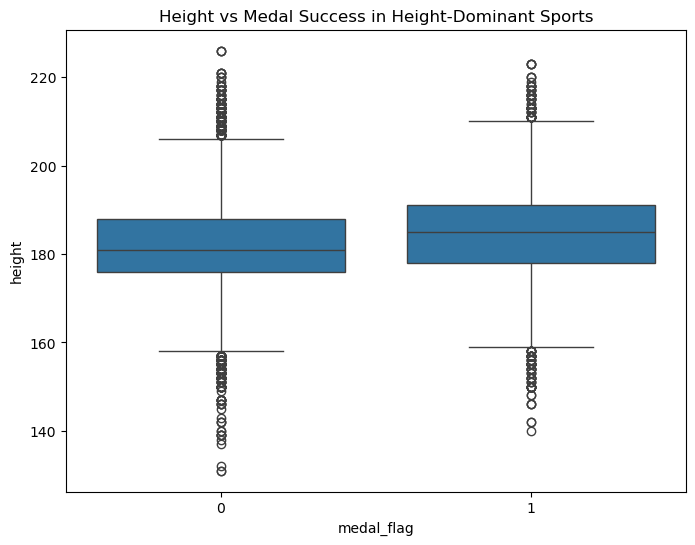

In [117]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='medal_flag',
    y='height',
    data=height_df
)

plt.title('Height vs Medal Success in Height-Dominant Sports')
plt.show()

In [120]:
weight_df.groupby('medal_flag')['weight'].mean()

medal_flag
0    72.867226
1    74.566074
Name: weight, dtype: float64

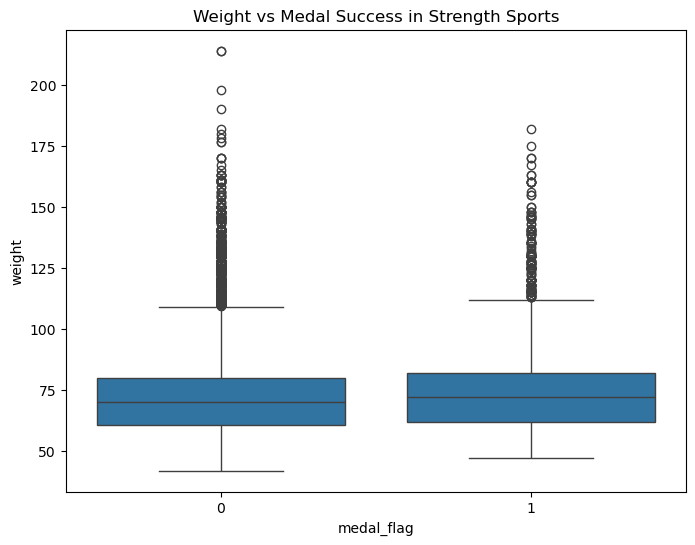

In [122]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='medal_flag',
    y='weight',
    data=weight_df
)

plt.title('Weight vs Medal Success in Strength Sports')

plt.show()

In [124]:
age_df.groupby('medal_flag')['age'].mean()

medal_flag
0    21.720920
1    22.108713
Name: age, dtype: float64

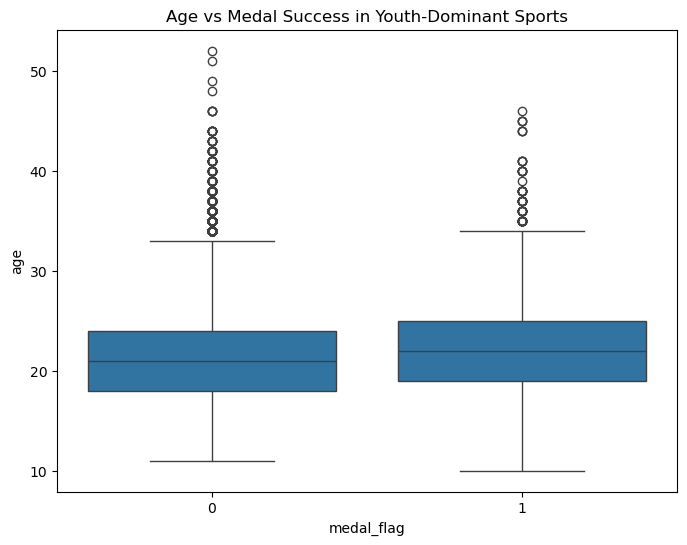

In [125]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='medal_flag',
    y='age',
    data=age_df
)

plt.title('Age vs Medal Success in Youth-Dominant Sports')

plt.show()

In [127]:
from scipy.stats import ttest_ind

medal_height = height_df[height_df['medal_flag']==1]['height'].dropna()
non_medal_height = height_df[height_df['medal_flag']==0]['height'].dropna()

ttest_ind(medal_height, non_medal_height)

TtestResult(statistic=22.61623182253423, pvalue=1.4290316830518745e-112, df=41728.0)

In [128]:
medal_weight = weight_df[weight_df['medal_flag']==1]['weight'].dropna()
non_medal_weight = weight_df[weight_df['medal_flag']==0]['weight'].dropna()

ttest_ind(medal_weight, non_medal_weight)

TtestResult(statistic=4.939373216115003, pvalue=7.897793753395524e-07, df=20937.0)

In [129]:
medal_age = age_df[age_df['medal_flag']==1]['age'].dropna()
non_medal_age = age_df[age_df['medal_flag']==0]['age'].dropna()

ttest_ind(medal_age, non_medal_age)

TtestResult(statistic=6.398148297394571, pvalue=1.5853189805580612e-10, df=55040.0)

# Analysis for Hypothesis 3

In [132]:
gender_trend = (
    df.groupby(['year','sex'])['id']
    .nunique()
    .reset_index(name='athlete_count')
)
gender_trend

,year,sex,athlete_count
0,1896,M,176
1,1900,F,23
2,1900,M,1201
3,1904,F,6
4,1904,M,644
...,...,...,...
64,2012,M,5863
65,2014,F,1102
66,2014,M,1643
67,2016,F,5034


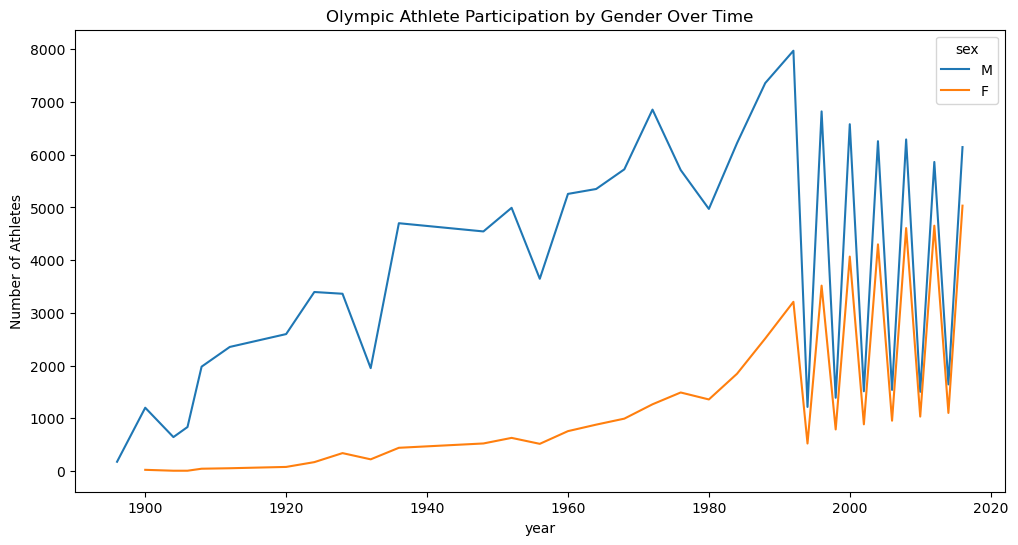

In [133]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=gender_trend,
    x='year',
    y='athlete_count',
    hue='sex'
)

plt.title('Olympic Athlete Participation by Gender Over Time')
plt.ylabel('Number of Athletes')

plt.show()

In [137]:
female_ratio = (
    df.groupby('year')['sex']
    .value_counts(normalize=True)
    .rename('percentage')
    .reset_index()
)


,year,sex,percentage
0,1896,M,1.000000
1,1900,M,0.982613
2,1900,F,0.017387
3,1904,M,0.987702
4,1904,F,0.012298
...,...,...,...
64,2012,F,0.450077
65,2014,M,0.586383
66,2014,F,0.413617
67,2016,M,0.545368


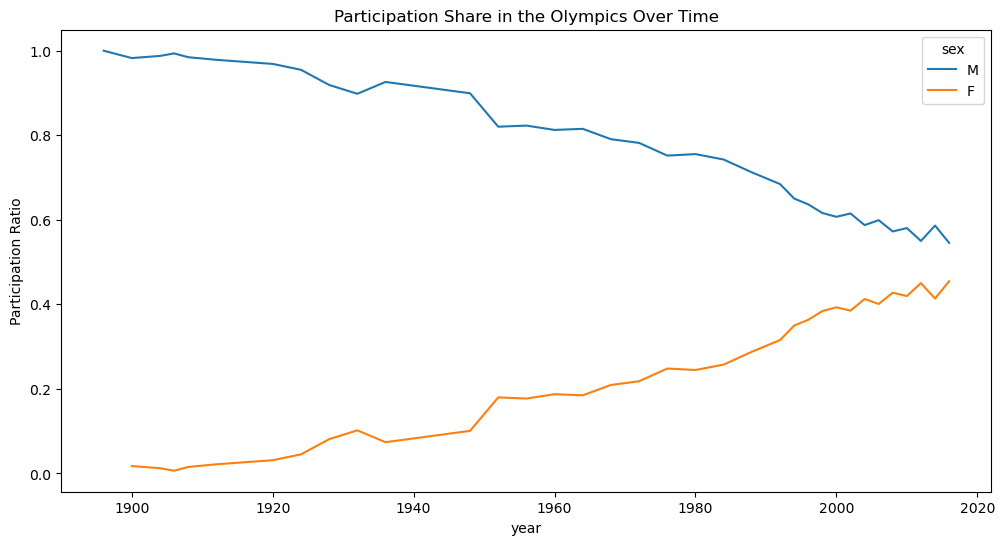

In [140]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=female_ratio,
    x='year',
    y='percentage',
    hue ='sex'
)

plt.title('Participation Share in the Olympics Over Time')
plt.ylabel( 'Participation Ratio')

plt.show()